# Diffusion Models for High-Resolution Image Generation & Reconstruction
### DDPM Implementation from Scratch using PyTorch (Kaggle Version)

**Dataset layout expected on Kaggle:**

```text
/kaggle/input/<dataset-name>/celebahq256_imgs/
    train/
    valid/
```

**Architecture Overview:**
- Forward Process: Gradual Gaussian noise addition using a fixed beta schedule
- Reverse Process: U-Net backbone learns to predict and remove noise
- Training: MSE loss between predicted and actual noise
- Evaluation: PSNR + SSIM metrics on held-out validation images
- Deployment: Gradio app with denoising visualization


In [1]:
# Kaggle setup
# The dataset should be added from Kaggle's right-side "Add Data" panel.
# Do NOT upload kaggle.json or download the dataset manually inside Kaggle.

!pip install -q gradio scikit-image

from pathlib import Path

input_root = Path('/kaggle/input')
print('Available Kaggle input datasets:')
if input_root.exists():
    for p in input_root.iterdir():
        print(' -', p)
else:
    print('/kaggle/input not found. This notebook is intended to run on Kaggle.')


Available Kaggle input datasets:
 - /kaggle/input/datasets


In [2]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# FIX M7: use the non-deprecated torch.amp path (PyTorch 2.x)
from torch.amp import GradScaler, autocast
import torchvision.transforms as transforms

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# FIX m7: ensure cuDNN is fully deterministic between runs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus  = torch.cuda.device_count()
print(f'Using device : {device}')
print(f'GPUs available: {n_gpus}')
for i in range(n_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')


Using device : cuda
GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
# ═══════════════════════════════════════════════════════════════
#  CENTRAL CONFIGURATION  –  Kaggle Settings
# ═══════════════════════════════════════════════════════════════
class Config:
    # Kaggle dataset structure expected:
    # /kaggle/input/<dataset-name>/celebahq256_imgs/train
    # /kaggle/input/<dataset-name>/celebahq256_imgs/valid
    KAGGLE_INPUT_ROOT = '/kaggle/input'
    DATASET_FOLDER_NAME = 'celebahq256_imgs'
    DATA_ROOT = None
    TRAIN_DIR = None
    VALID_DIR = None

    # Data
    IMG_SIZE        = 128         # assignment minimum is 128x128
    BATCH_SIZE      = 16          # reduce to 8 if Kaggle T4 runs out of memory
    NUM_WORKERS     = 2           # safe value for Kaggle notebooks

    # Diffusion
    T               = 300         # recommended range: 200–500
    BETA_START      = 1e-4
    BETA_END        = 0.02

    # U-Net
    BASE_CHANNELS   = 64          # channel progression: 64→128→256
    TIME_EMB_DIM    = 256
    NUM_RES_BLOCKS  = 2

    # Training
    EPOCHS          = 15
    LR              = 2e-4
    GRAD_CLIP       = 1.0
    MIXED_PRECISION = True

    # Sampling
    NUM_SAMPLE_IMGS = 5

    # Paths: files saved here can be downloaded from Kaggle after the run
    SAVE_DIR        = '/kaggle/working/ddpm_checkpoints'


def resolve_dataset_dirs(cfg):
    """Finds celebahq256_imgs/train and celebahq256_imgs/valid inside /kaggle/input."""
    input_root = Path(cfg.KAGGLE_INPUT_ROOT)
    if not input_root.exists():
        raise FileNotFoundError(
            f'{cfg.KAGGLE_INPUT_ROOT} not found. Run this notebook on Kaggle and add the dataset from Add Data.'
        )

    # Prefer the exact folder name provided by the dataset layout.
    for root in input_root.rglob(cfg.DATASET_FOLDER_NAME):
        train_dir = root / 'train'
        valid_dir = root / 'valid'
        if train_dir.is_dir() and valid_dir.is_dir():
            return str(root), str(train_dir), str(valid_dir)

    # Fallback: find any folder with train/valid subfolders.
    for root in input_root.rglob('*'):
        if root.is_dir() and (root / 'train').is_dir() and (root / 'valid').is_dir():
            return str(root), str(root / 'train'), str(root / 'valid')

    raise FileNotFoundError(
        'Could not find a dataset folder with train/valid splits. Expected something like: '
        '/kaggle/input/<dataset-name>/celebahq256_imgs/train and valid'
    )


cfg = Config()
cfg.DATA_ROOT, cfg.TRAIN_DIR, cfg.VALID_DIR = resolve_dataset_dirs(cfg)
os.makedirs(cfg.SAVE_DIR, exist_ok=True)

print('Config loaded ✓')
print(f'  Data root    : {cfg.DATA_ROOT}')
print(f'  Train dir    : {cfg.TRAIN_DIR}')
print(f'  Valid dir    : {cfg.VALID_DIR}')
print(f'  Image size   : {cfg.IMG_SIZE}x{cfg.IMG_SIZE}')
print(f'  Timesteps T  : {cfg.T}')
print(f'  Epochs       : {cfg.EPOCHS}')
print(f'  Save dir     : {cfg.SAVE_DIR}')


Config loaded ✓
  Data root    : /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs
  Train dir    : /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train
  Valid dir    : /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid
  Image size   : 128x128
  Timesteps T  : 300
  Epochs       : 15
  Save dir     : /kaggle/working/ddpm_checkpoints


Found 27,000 images in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train
Found 3,000 images in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid
Train images       : 27,000
Validation images  : 3,000
Batches per epoch  : 1,687


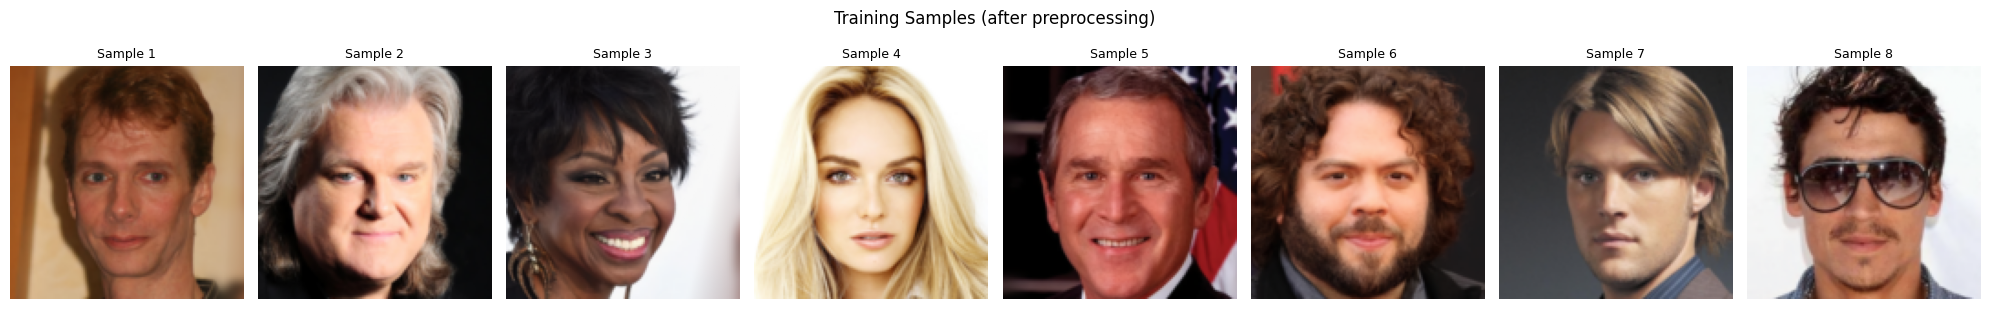

In [4]:
class ImageFolderDataset(Dataset):
    """Recursively loads all images from a directory tree."""
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir  = Path(root_dir)
        self.transform = transform
        self.paths = sorted([
            p for p in self.root_dir.rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ])
        print(f'Found {len(self.paths):,} images in {root_dir}')
        if len(self.paths) == 0:
            raise RuntimeError(f'No images found in {root_dir}. Check the Kaggle dataset path.')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                            # [0,1]
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),           # -> [-1, 1]
])

valid_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

train_dataset = ImageFolderDataset(cfg.TRAIN_DIR, transform=train_transform)
valid_dataset = ImageFolderDataset(cfg.VALID_DIR, transform=valid_transform)

dataset = train_dataset  # backward-compatible alias

# FIX m4: persistent_workers=True avoids respawning workers every epoch
dataloader = DataLoader(
    train_dataset,
    batch_size        = cfg.BATCH_SIZE,
    shuffle           = True,
    num_workers       = cfg.NUM_WORKERS,
    pin_memory        = True,
    drop_last         = True,
    persistent_workers= cfg.NUM_WORKERS > 0,
)

val_loader = DataLoader(
    valid_dataset,
    batch_size        = cfg.BATCH_SIZE,
    shuffle           = False,
    num_workers       = cfg.NUM_WORKERS,
    pin_memory        = True,
    drop_last         = False,
    persistent_workers= cfg.NUM_WORKERS > 0,
)

print(f'Train images       : {len(train_dataset):,}')
print(f'Validation images  : {len(valid_dataset):,}')
print(f'Batches per epoch  : {len(dataloader):,}')

sample_batch = next(iter(dataloader))

# ── Utility ───────────────────────────────────────────────────────────────────
def denorm(tensor):
    """[-1,1] -> [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# ── Visualise sample images ───────────────────────────────────────────────────
n_show = min(8, sample_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    img_np = denorm(sample_batch[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=9)
plt.suptitle('Training Samples (after preprocessing)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


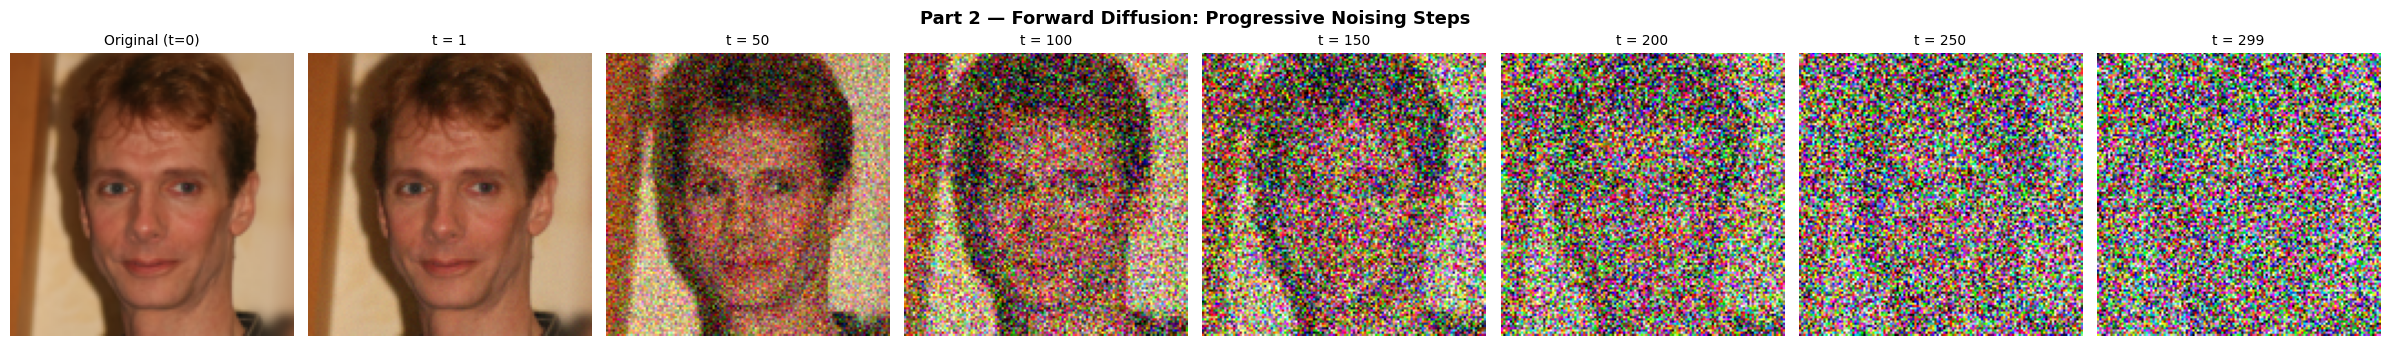

In [5]:
class GaussianDiffusion:
    def __init__(self, T: int, beta_start: float, beta_end: float, device):
        self.T      = T
        self.device = device

        betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
        alphas          = 1.0 - betas
        alphas_cumprod  = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas                       = betas.to(device)
        self.alphas                      = alphas.to(device)
        self.alphas_cumprod              = alphas_cumprod.to(device)
        self.alphas_cumprod_prev         = alphas_cumprod_prev.to(device)

        self.sqrt_alphas_cumprod         = torch.sqrt(alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod).to(device)

        # FIX M5: posterior_variance[0] = 0, clamp log to avoid -inf
        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.posterior_variance      = posterior_variance.to(device)
        self.posterior_log_variance  = torch.log(posterior_variance.clamp(min=1e-20)).to(device)

        self.posterior_mean_coef1 = (torch.sqrt(alphas_cumprod_prev) * betas
                                     / (1.0 - alphas_cumprod)).to(device)
        self.posterior_mean_coef2 = (torch.sqrt(alphas) * (1.0 - alphas_cumprod_prev)
                                     / (1.0 - alphas_cumprod)).to(device)

    @staticmethod
    def _extract(a, t, x_shape):
        batch = t.shape[0]
        out   = a.gather(0, t)
        return out.view(batch, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_ac   = self._extract(self.sqrt_alphas_cumprod,            t, x_start.shape)
        sqrt_1mac = self._extract(self.sqrt_one_minus_alphas_cumprod,  t, x_start.shape)
        return sqrt_ac * x_start + sqrt_1mac * noise

    def predict_x0_from_noise(self, x_t, t, noise_pred):
        sqrt_ac   = self._extract(self.sqrt_alphas_cumprod,            t, x_t.shape)
        sqrt_1mac = self._extract(self.sqrt_one_minus_alphas_cumprod,  t, x_t.shape)
        return (x_t - sqrt_1mac * noise_pred) / sqrt_ac

    def q_posterior(self, x_start, x_t, t):
        mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
          + self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        var     = self._extract(self.posterior_variance,     t, x_t.shape)
        log_var = self._extract(self.posterior_log_variance, t, x_t.shape)
        return mean, var, log_var

    @torch.no_grad()
    def p_sample(self, model, x_t, t_idx):
        t_tensor   = torch.full((x_t.shape[0],), t_idx, device=self.device, dtype=torch.long)
        noise_pred = model(x_t, t_tensor)

        x0_pred = self.predict_x0_from_noise(x_t, t_tensor, noise_pred)
        x0_pred = x0_pred.clamp(-1, 1)

        mean, _, log_var = self.q_posterior(x0_pred, x_t, t_tensor)

        # FIX M5: at t=0 the posterior variance is 0; return mean deterministically
        if t_idx == 0:
            return mean
        noise = torch.randn_like(x_t)
        return mean + (0.5 * log_var).exp() * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False):
        # FIX m3: save and restore the model's training mode
        was_training = model.training
        model.eval()

        x = torch.randn(shape, device=self.device)
        intermediates = [x.clone()] if return_intermediates else []

        for t in tqdm(reversed(range(self.T)), desc='Sampling', total=self.T, leave=False):
            x = self.p_sample(model, x, t)
            if return_intermediates and t % (self.T // 10) == 0:
                intermediates.append(x.clone())

        # restore original mode
        model.train(was_training)

        if return_intermediates:
            return x, intermediates
        return x

diffusion = GaussianDiffusion(cfg.T, cfg.BETA_START, cfg.BETA_END, device)

# ── Visualise forward diffusion (Part 2, Task 4) ─────────────────────────────
# FIX m5: label t=0 explicitly as the original image; show 7 steps including pure noise
vis_img = sample_batch[0:1].to(device)
steps_to_show  = [1, 50, 100, 150, 200, 250, cfg.T - 1]
step_labels    = [f't = {s}' for s in steps_to_show]
noisy_imgs     = []

# Add original (t=0) as first panel
noisy_imgs.append(vis_img.squeeze(0).cpu())

for t_val in steps_to_show:
    t_tensor = torch.tensor([t_val], device=device)
    noisy    = diffusion.q_sample(vis_img, t_tensor)
    noisy_imgs.append(noisy.squeeze(0).cpu())

all_labels = ['Original (t=0)'] + step_labels
n_panels   = len(all_labels)

fig, axes = plt.subplots(1, n_panels, figsize=(3 * n_panels, 3.5))
for ax, img_t, lbl in zip(axes, noisy_imgs, all_labels):
    ax.imshow(denorm(img_t).permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(lbl, fontsize=10)
    ax.axis('off')
plt.suptitle('Part 2 — Forward Diffusion: Progressive Noising Steps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
class SinusoidalPositionEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half_dim  = self.dim // 2
        # FIX m1: standard formula divides by half_dim, not half_dim-1
        emb_scale = math.log(10_000) / half_dim
        emb       = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb       = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class TimeEmbeddingMLP(nn.Module):
    def __init__(self, emb_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalPositionEmbedding(emb_dim),
            nn.Linear(emb_dim, out_dim * 4),
            nn.SiLU(),
            nn.Linear(out_dim * 4, out_dim),
        )
    def forward(self, t):
        return self.net(t)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int):
        super().__init__()
        # FIX m2: clamp groups so GroupNorm never errors on small channel counts
        g1 = min(8, in_ch)
        g2 = min(8, out_ch)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch * 2))

        self.block1 = nn.Sequential(
            nn.GroupNorm(g1, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(g2, out_ch),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h            = self.block1(x)
        t_out        = self.time_mlp(time_emb)
        scale, shift = t_out.chunk(2, dim=-1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class SelfAttention(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # FIX m2: groups clamped to actual channel count
        groups     = min(8, channels)
        self.norm  = nn.GroupNorm(groups, channels)
        self.qkv   = nn.Conv2d(channels, channels * 3, 1)
        self.proj  = nn.Conv2d(channels, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h          = self.norm(x)
        qkv        = self.qkv(h).view(B, 3, C, H * W)
        q, k, v    = qkv.unbind(1)           # each: (B, C, HW)
        scale      = C ** -0.5
        # FIX M6: correct Q·Kᵀ — q:(B,C,HW) → (B,HW,C)  k:(B,C,HW)
        #          bmm((B,HW,C), (B,C,HW)) → attn (B,HW,HW)  ✓
        attn  = torch.softmax(torch.bmm(q.transpose(1, 2), k) * scale, dim=-1)
        # v:(B,C,HW) bmm attn.T:(B,HW,HW) → (B,C,HW) ✓
        out   = torch.bmm(v, attn.transpose(1, 2)).view(B, C, H, W)
        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x): return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x): return self.conv(self.up(x))


class UNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, time_emb_dim=256, num_res_blocks=2):
        super().__init__()
        # FIX M1: save original in_channels under a distinct name so the
        #          decoder loop can't shadow it
        img_ch   = in_channels
        ch       = base_channels
        ch_mult  = (1, 2, 4)
        channels = [ch * m for m in ch_mult]

        self.time_mlp  = TimeEmbeddingMLP(time_emb_dim, time_emb_dim)
        self.init_conv = nn.Conv2d(img_ch, channels[0], 3, padding=1)

        # ── Encoder ────────────────────────────────────────────────────────
        self.enc_blocks    = nn.ModuleList()
        self.downsamples   = nn.ModuleList()
        self.skip_channels = []
        in_ch = channels[0]

        for level, out_ch in enumerate(channels):
            blocks = nn.ModuleList()
            for _ in range(num_res_blocks):
                blocks.append(ResidualBlock(in_ch, out_ch, time_emb_dim))
                in_ch = out_ch
            self.enc_blocks.append(blocks)
            self.skip_channels.append(out_ch)
            if level < len(channels) - 1:
                self.downsamples.append(Downsample(out_ch))
            else:
                self.downsamples.append(nn.Identity())

        # ── Bottleneck ─────────────────────────────────────────────────────
        btn_ch           = channels[-1]
        self.mid_block1  = ResidualBlock(btn_ch, btn_ch, time_emb_dim)
        self.mid_attn    = SelfAttention(btn_ch)
        self.mid_block2  = ResidualBlock(btn_ch, btn_ch, time_emb_dim)

        # ── Decoder ────────────────────────────────────────────────────────
        # FIX M2: each decoder level has exactly (num_res_blocks + 1) blocks.
        #   Block 0 takes (in_ch + skip_ch) because skip is concatenated before
        #   the block loop. Blocks 1..num_res_blocks take (out_ch) because the
        #   skip has already been consumed. This is deterministic for any value
        #   of num_res_blocks and avoids the brittle i==0 index trick.
        self.dec_blocks  = nn.ModuleList()
        self.upsamples   = nn.ModuleList()
        rev_channels     = list(reversed(channels))

        for level, out_ch in enumerate(rev_channels):
            skip_ch = self.skip_channels[-(level + 1)]
            blocks  = nn.ModuleList()
            # first block: input = current features + skip
            blocks.append(ResidualBlock(in_ch + skip_ch, out_ch, time_emb_dim))
            # remaining blocks: input = out_ch
            for _ in range(num_res_blocks):
                blocks.append(ResidualBlock(out_ch, out_ch, time_emb_dim))
            in_ch = out_ch
            self.dec_blocks.append(blocks)
            if level < len(rev_channels) - 1:
                self.upsamples.append(Upsample(out_ch))
            else:
                self.upsamples.append(nn.Identity())

        # ── Output head ────────────────────────────────────────────────────
        # FIX M1: use img_ch (the saved constructor param) not the shadowed in_ch
        out_groups       = min(8, channels[0])
        self.out_norm    = nn.GroupNorm(out_groups, channels[0])
        self.out_act     = nn.SiLU()
        self.out_conv    = nn.Conv2d(channels[0], img_ch, 1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        x     = self.init_conv(x)

        # Encoder
        skips = []
        for blocks, down in zip(self.enc_blocks, self.downsamples):
            for blk in blocks:
                x = blk(x, t_emb)
            skips.append(x)
            x = down(x)

        # Bottleneck
        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        # Decoder — FIX M2: cat happens once before block[0], then blocks run in order
        for blocks, up, skip in zip(self.dec_blocks, self.upsamples, reversed(skips)):
            x = torch.cat([x, skip], dim=1)   # concat skip → feeds block[0]
            for blk in blocks:
                x = blk(x, t_emb)
            x = up(x)

        x = self.out_norm(x)
        x = self.out_act(x)
        return self.out_conv(x)


model = UNet(
    in_channels    = 3,
    base_channels  = cfg.BASE_CHANNELS,
    time_emb_dim   = cfg.TIME_EMB_DIM,
    num_res_blocks = cfg.NUM_RES_BLOCKS,
).to(device)

if n_gpus > 1:
    model = nn.DataParallel(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net created ✓  |  Parameters: {n_params/1e6:.2f}M')


U-Net created ✓  |  Parameters: 14.21M


Starting training …


Epoch 1/15 [train]:   0%|          | 0/1687 [00:00<?, ?it/s]

Epoch 1/15 [val]  :   0%|          | 0/188 [00:00<?, ?it/s]

  Epoch 001 | train=0.05147 | val=0.02883 | lr=1.98e-04
    ↳ New best val loss 0.02883 — checkpoint saved.


Epoch 2/15 [train]:   0%|          | 0/1687 [00:00<?, ?it/s]

...

Epoch 14/15 [val]  :   0%|          | 0/188 [00:00<?, ?it/s]

  Epoch 014 | train=0.02175 | val=0.02127 | lr=3.17e-06


Epoch 15/15 [train]:   0%|          | 0/1687 [00:00<?, ?it/s]

Epoch 15/15 [val]  :   0%|          | 0/188 [00:00<?, ?it/s]

  Epoch 015 | train=0.02162 | val=0.02247 | lr=1.00e-06

Training complete in 124.5 min  |  Best val loss: 0.02040


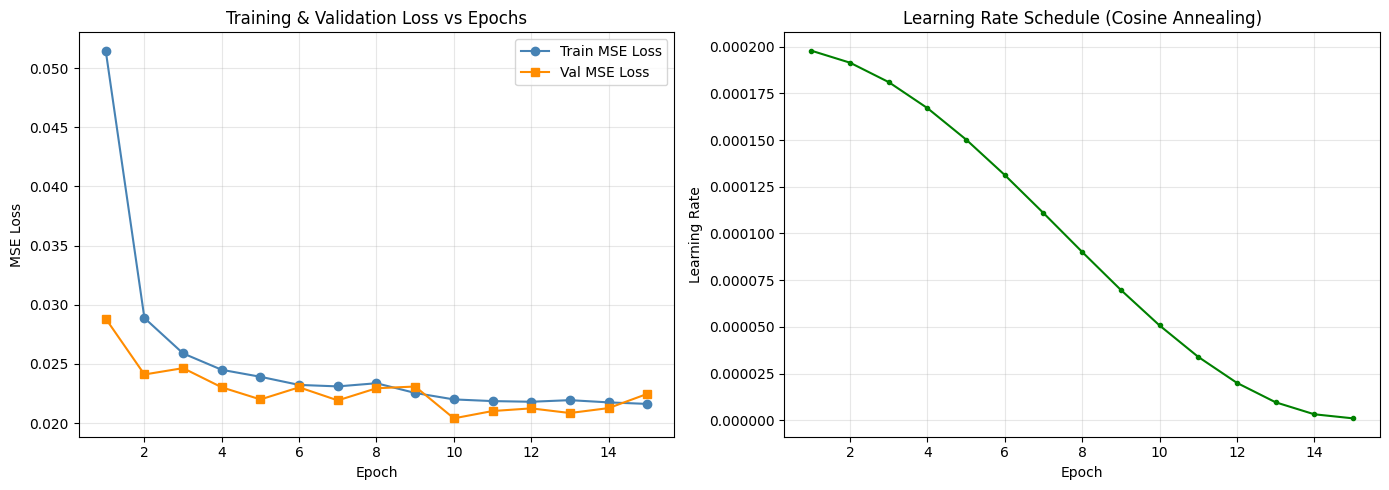

Training diagnostics saved.


In [7]:
# FIX M7: GradScaler now uses device_type argument (PyTorch 2.x API)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
scaler    = GradScaler(device='cuda' if torch.cuda.is_available() else 'cpu',
                       enabled=cfg.MIXED_PRECISION)
loss_fn   = nn.MSELoss()

train_losses = []
val_losses   = []
lr_history   = []
best_loss    = float('inf')   # FIX M8: now tracks VALIDATION loss
start_epoch  = 0
ckpt_path    = f'{cfg.SAVE_DIR}/best_model.pth'


def get_bare_model(m):
    """Unwrap DataParallel if present, so state_dict has clean keys."""
    return m.module if isinstance(m, nn.DataParallel) else m


def train_one_epoch(model, dataloader, optimizer, scaler, diffusion, epoch):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{cfg.EPOCHS} [train]', leave=True)

    for x0 in pbar:
        x0    = x0.to(device, non_blocking=True)
        B     = x0.shape[0]
        t     = torch.randint(0, cfg.T, (B,), device=device)
        noise = torch.randn_like(x0)
        x_t   = diffusion.q_sample(x0, t, noise)

        # FIX M7: pass device_type to autocast
        with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu',
                      enabled=cfg.MIXED_PRECISION):
            noise_pred = model(x_t, t)
            loss       = loss_fn(noise_pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if cfg.GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.5f}',
                          'lr'  : f'{optimizer.param_groups[0]["lr"]:.2e}'})

    return epoch_loss / len(dataloader)


# FIX M8: dedicated validation pass — no gradients, no dropout
@torch.no_grad()
def validate_one_epoch(model, val_loader, diffusion, epoch):
    model.eval()
    epoch_loss = 0.0
    pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{cfg.EPOCHS} [val]  ', leave=False)

    for x0 in pbar:
        x0    = x0.to(device, non_blocking=True)
        B     = x0.shape[0]
        t     = torch.randint(0, cfg.T, (B,), device=device)
        noise = torch.randn_like(x0)
        x_t   = diffusion.q_sample(x0, t, noise)

        with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu',
                      enabled=cfg.MIXED_PRECISION):
            noise_pred = model(x_t, t)
            loss       = loss_fn(noise_pred, noise)

        epoch_loss += loss.item()
        pbar.set_postfix({'val_loss': f'{loss.item():.5f}'})

    return epoch_loss / len(val_loader)


print('Starting training …')
total_start = time.time()

for epoch in range(start_epoch, cfg.EPOCHS):
    avg_train = train_one_epoch(model, dataloader, optimizer, scaler, diffusion, epoch)
    avg_val   = validate_one_epoch(model, val_loader, diffusion, epoch)
    scheduler.step()

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    lr_history.append(optimizer.param_groups[0]['lr'])

    print(f'  Epoch {epoch+1:03d} | train={avg_train:.5f} | val={avg_val:.5f} '
          f'| lr={lr_history[-1]:.2e}')

    # FIX M4 + M8: save on VALIDATION loss; use bare model state_dict
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save({
            'epoch'    : epoch,
            'model'    : get_bare_model(model).state_dict(),  # FIX M4: no module. prefix
            'optimizer': optimizer.state_dict(),
            'loss'     : best_loss,
            'train_losses': train_losses,
            'val_losses'  : val_losses,
            'config'   : vars(cfg),
        }, ckpt_path)
        print(f'    ↳ New best val loss {best_loss:.5f} — checkpoint saved.')

elapsed = time.time() - total_start
print(f'\nTraining complete in {elapsed/60:.1f} min  |  Best val loss: {best_loss:.5f}')

# ── Training diagnostics (R3) ─────────────────────────────────────────────────
epochs_x = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_x, train_losses, marker='o', label='Train MSE Loss', color='steelblue')
ax1.plot(epochs_x, val_losses,   marker='s', label='Val MSE Loss',   color='darkorange')
ax1.set_title('Training & Validation Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# LR schedule
ax2.plot(epochs_x, lr_history, marker='.', color='green')
ax2.set_title('Learning Rate Schedule (Cosine Annealing)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training diagnostics saved.')


In [8]:
# FIX M4: load into bare model — state_dict keys no longer have 'module.' prefix
best_ckpt  = torch.load(ckpt_path, map_location=device)
bare_model = get_bare_model(model)
bare_model.load_state_dict(best_ckpt['model'])
model.eval()

# ── Part 6: Generate 5 images from pure noise ─────────────────────────────────
print('Generating images from pure Gaussian noise …')
gen_shape  = (cfg.NUM_SAMPLE_IMGS, 3, cfg.IMG_SIZE, cfg.IMG_SIZE)
generated, intermediates = diffusion.p_sample_loop(model, gen_shape, return_intermediates=True)

fig, axes = plt.subplots(1, cfg.NUM_SAMPLE_IMGS, figsize=(4 * cfg.NUM_SAMPLE_IMGS, 4))
if cfg.NUM_SAMPLE_IMGS == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(denorm(generated[i]).permute(1, 2, 0).cpu().numpy().clip(0, 1))
    ax.set_title(f'Generated {i+1}', fontsize=11)
    ax.axis('off')
plt.suptitle('Part 6 — Generated Images from Pure Noise', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/generated_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ── R2: Visualise 5 intermediate reverse diffusion steps (for image 0) ────────
# p_sample_loop collected ~10 checkpoints; pick 5 evenly spaced + final
if intermediates:
    # intermediates[0] = pure noise, intermediates[-1] ≈ clean; pick 5 in between
    idx_picks   = [0, len(intermediates)//4, len(intermediates)//2,
                   3*len(intermediates)//4, len(intermediates)-1]
    idx_picks   = sorted(set(idx_picks))[:5]   # deduplicate & cap at 5
    step_frames = [intermediates[i][0].cpu() for i in idx_picks]
    step_titles = ['Pure noise'] + [f'Step {i}' for i in idx_picks[1:-1]] + ['Final']
    step_titles = step_titles[:len(step_frames)]

    fig, axes = plt.subplots(1, len(step_frames), figsize=(4 * len(step_frames), 4))
    if len(step_frames) == 1:
        axes = [axes]
    for ax, img_t, ttl in zip(axes, step_frames, step_titles):
        ax.imshow(denorm(img_t).permute(1, 2, 0).numpy().clip(0, 1))
        ax.set_title(ttl, fontsize=10)
        ax.axis('off')
    plt.suptitle('R2 — Reverse Diffusion: 5 Intermediate Denoising Steps', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{cfg.SAVE_DIR}/reverse_steps.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Part 5: Reconstruction task ───────────────────────────────────────────────
# FIX M9: raise noise_level_frac to 0.85 for a challenging, honest reconstruction
def reconstruct_image(model, diffusion, target_tensor, noise_level_frac=0.85):
    """
    Start from a heavily noised version of target_tensor (frac=0.85 → t=255 for T=300),
    then run the full reverse process back to t=0.
    """
    was_training = model.training
    model.eval()

    x0       = target_tensor.unsqueeze(0).to(device)
    t_start  = int(diffusion.T * noise_level_frac)
    t_tensor = torch.tensor([t_start], device=device)
    noise    = torch.randn_like(x0)
    x_t      = diffusion.q_sample(x0, t_tensor, noise)

    x = x_t.clone()
    with torch.no_grad():
        for t_idx in tqdm(reversed(range(t_start)), desc='Reconstructing',
                          total=t_start, leave=False):
            x = diffusion.p_sample(model, x, t_idx)

    model.train(was_training)
    return x.squeeze(0).cpu()


target_img    = valid_dataset[0]
reconstructed = reconstruct_image(model, diffusion, target_img, noise_level_frac=0.85)

# 3-panel: original | noisy input | reconstructed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
t_show   = int(cfg.T * 0.85)
orig_np  = denorm(target_img).permute(1, 2, 0).numpy().clip(0, 1)
noisy_np = denorm(
    diffusion.q_sample(target_img.unsqueeze(0).to(device),
                       torch.tensor([t_show], device=device)).squeeze(0).cpu()
).permute(1, 2, 0).numpy().clip(0, 1)
recon_np = denorm(reconstructed).permute(1, 2, 0).numpy().clip(0, 1)

for ax, img, title in zip(axes,
                           [orig_np, noisy_np, recon_np],
                           [f'Target (validation)', f'Noisy input (t={t_show})', 'Reconstructed']):
    ax.imshow(img)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')
plt.suptitle('Part 5 — Image Reconstruction Task', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

# ── R1: Side-by-side Target vs Generated comparison grid ─────────────────────
n_compare  = min(5, len(valid_dataset), generated.shape[0])
fig, axes  = plt.subplots(2, n_compare, figsize=(4 * n_compare, 8))
axes[0, 0].set_ylabel('Target (val)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Generated',    fontsize=12, fontweight='bold')

for col in range(n_compare):
    tgt_np = denorm(valid_dataset[col]).permute(1, 2, 0).numpy().clip(0, 1)
    gen_np = denorm(generated[col]).permute(1, 2, 0).cpu().numpy().clip(0, 1)
    axes[0, col].imshow(tgt_np)
    axes[0, col].set_title(f'Target {col+1}', fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].imshow(gen_np)
    axes[1, col].set_title(f'Generated {col+1}', fontsize=10)
    axes[1, col].axis('off')

plt.suptitle('R1 — Side-by-side: Validation Targets vs Generated Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/target_vs_generated.png', dpi=150, bbox_inches='tight')
plt.show()


Generating images from pure Gaussian noise …


Sampling:   0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
def compute_metrics(original_tensor, generated_tensor):
    orig_np = denorm(original_tensor).permute(1, 2, 0).numpy().clip(0, 1)
    gen_np  = denorm(generated_tensor).permute(1, 2, 0).numpy().clip(0, 1)
    psnr_val = psnr_metric(orig_np, gen_np, data_range=1.0)
    # FIX m6: win_size fixed to 7 (odd, always < 128px image side)
    ssim_val = ssim_metric(
        orig_np,
        gen_np,
        data_range=1.0,
        channel_axis=-1,
        win_size=7,
    )
    return psnr_val, ssim_val

n_eval = min(5, len(valid_dataset))
print(f'Computing PSNR & SSIM on {n_eval} held-out validation images '
      f'(reconstruction from noise_level_frac=0.85) …')

psnr_scores, ssim_scores = [], []
for i in range(n_eval):
    tgt  = valid_dataset[i]
    # FIX M9: consistent frac with reconstruction cell
    rec  = reconstruct_image(model, diffusion, tgt, noise_level_frac=0.85)
    p, s = compute_metrics(tgt, rec)
    psnr_scores.append(p)
    ssim_scores.append(s)
    print(f'  Validation Image {i+1}: PSNR = {p:.2f} dB  |  SSIM = {s:.4f}')

print(f'\n  Mean PSNR : {sum(psnr_scores)/len(psnr_scores):.2f} dB')
print(f'  Mean SSIM : {sum(ssim_scores)/len(ssim_scores):.4f}')


In [ ]:
import gradio as gr

@torch.no_grad()
def gradio_generate(num_images, show_steps, seed):
    torch.manual_seed(int(seed))
    model.eval()
    n = int(num_images)

    x           = torch.randn(n, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
    step_gap    = max(1, cfg.T // int(show_steps))
    collect_at  = set(range(0, cfg.T, step_gap))
    frame_list  = []

    for t_idx in reversed(range(cfg.T)):
        x = diffusion.p_sample(model, x, t_idx)
        if t_idx in collect_at:
            frame_list.append(
                denorm(x[0]).permute(1, 2, 0).cpu().numpy().clip(0, 1)
            )

    # Final PIL images for the gallery
    final_pils = [
        Image.fromarray(
            (denorm(x[i]).permute(1, 2, 0).cpu().numpy().clip(0, 1) * 255).astype(np.uint8)
        )
        for i in range(n)
    ]

    # Denoising strip (image 0 intermediates)
    n_frames = len(frame_list)
    strip_w  = cfg.IMG_SIZE * n_frames
    strip    = np.zeros((cfg.IMG_SIZE, strip_w, 3), dtype=np.uint8)
    for idx, frame in enumerate(frame_list):
        strip[:, idx * cfg.IMG_SIZE:(idx + 1) * cfg.IMG_SIZE, :] = (frame * 255).astype(np.uint8)
    strip_pil = Image.fromarray(strip)

    # FIX M3: return a proper tuple matching the two Gradio output components
    return final_pils, strip_pil


with gr.Blocks(title='DDPM Image Generator') as demo:
    gr.Markdown('# DDPM Image Generator\nBuilt from scratch with PyTorch — Assignment 4')
    with gr.Row():
        with gr.Column(scale=1):
            num_imgs   = gr.Slider(1, 5,  value=3, step=1,  label='Number of images')
            num_steps  = gr.Slider(5, 20, value=10, step=1, label='Denoising steps to show')
            seed_input = gr.Number(value=42, label='Random seed', precision=0)
            gen_btn    = gr.Button('Generate')
        with gr.Column(scale=3):
            output_gallery = gr.Gallery(label='Generated images')
            step_strip     = gr.Image(label='Denoising step strip (image 1)', type='pil')

    gen_btn.click(
        fn      = gradio_generate,
        inputs  = [num_imgs, num_steps, seed_input],
        outputs = [output_gallery, step_strip],   # FIX M3: matches 2-element tuple return
    )

print('Launching Gradio app …')
# FIX m8: share=True generates a public tunnel accessible outside Kaggle's kernel
demo.launch(share=True, debug=False)
